In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures

In [8]:
model = PolynomialFeatures(degree=3, include_bias=False)

model.fit_transform([[2, 3], [4, 5]])

array([[  2.,   3.,   4.,   6.,   9.,   8.,  12.,  18.,  27.],
       [  4.,   5.,  16.,  20.,  25.,  64.,  80., 100., 125.]])

# Створення поліноміальних ознак

[[a1=2, b1=3], 
 [a2=4, b2=5]]

[a1, b1, a1^2, a1 * b1, b1^2, a1^3, a1^2 * b1, b1^2 * a1, b1^3]
[a2, b2, a2^2, a2 * b2, b2^2, a2^3, a2^2 * b2, b2^2 * a2, b2^3]

In [12]:
np.random.seed(42)
x = np.linspace(-3, 3, 200)
y = 1.5 * x - 0.8 * x ** 2 + 2 + np.random.normal(0, 1.2, size=200)
X = x.reshape(-1, 1)

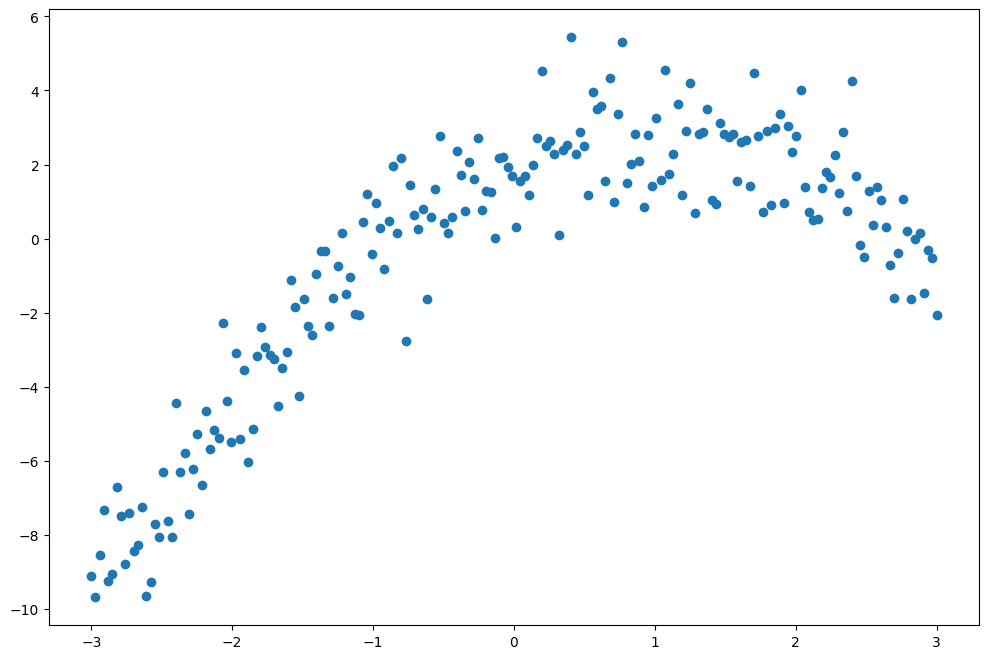

In [13]:
plt.figure(figsize=(12, 8))

plt.scatter(x, y)

plt.show()

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

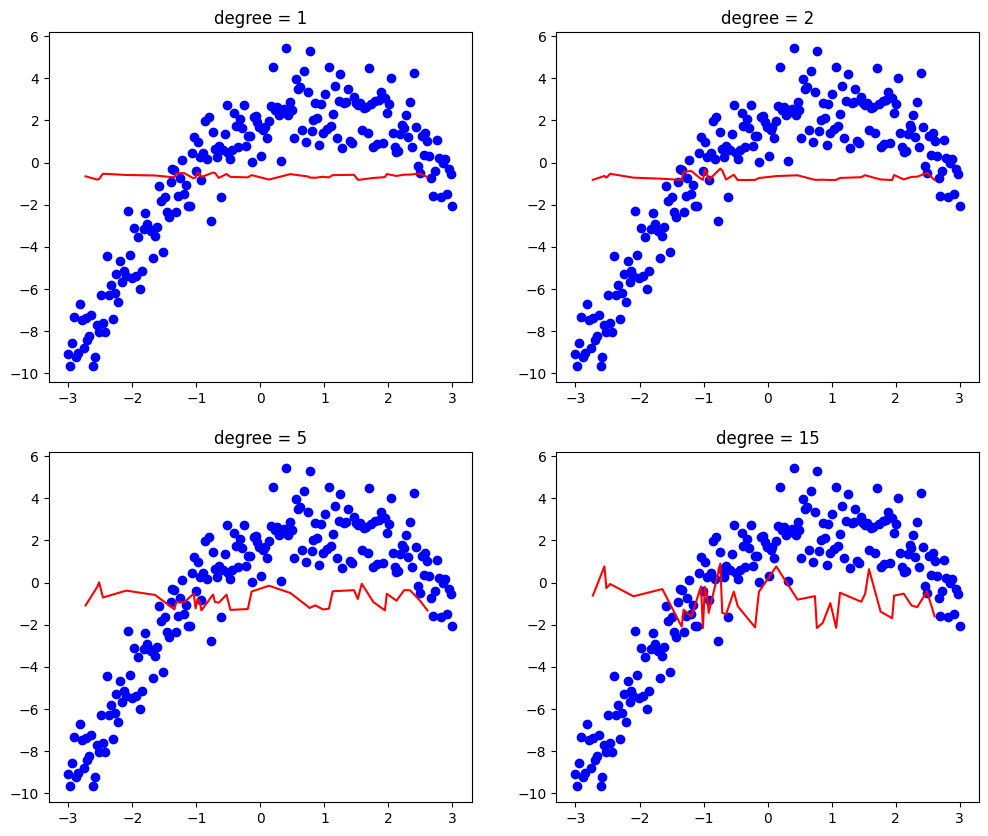

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

metrics = []

plt.figure(figsize=(12, 10))

n = 0
for d in [1, 2, 5, 15]:
    n += 1
    plt.subplot(2, 2, n)
    
    model = Pipeline(steps=[
        ("poly", PolynomialFeatures(d, include_bias=False)),
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression())
    ])
    
    model.fit(X_train, y_train)
    
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    plt.scatter(x, y, color='blue')
    indx_sort = np.argsort(X_test[:, 0])
    plt.plot(X_test[indx_sort], y_pred_test, color='red')
    plt.title("degree = " + str(d))
    
    metrics.append({
        "degree": d,
        "r2_train": r2_score(y_train, y_pred_train),
        "r2_test": r2_score(y_test, y_pred_test)
    })
    
plt.show()


In [19]:
pd.DataFrame(metrics)

,degree,r2_train,r2_test
0,1,0.548510,0.492246
1,2,0.907735,0.897404
2,5,0.911491,0.900050
3,15,0.914993,0.894905
